# Spatial transcriptomics in Python: a first Visium analysis

**Biological question:** do gene-expression patterns and spatial relationships recover known anatomical regions in a mouse brain section?

By the end, you will be able to explain a Visium spot, inspect an `AnnData` object, evaluate spot-level QC, build a spatial-neighbor graph, interpret neighborhood enrichment, and use Moran's I to find spatially patterned genes.


## Mental model

A standard RNA-seq matrix tells us **what** genes are expressed. Spatial transcriptomics also records **where** each measurement came from. In this Visium dataset:

- each observation is a capture **spot**, not necessarily one cell;
- each variable is a gene;
- `adata.X` stores expression values;
- `adata.obs` and `adata.var` store spot and gene metadata;
- `adata.obsm['spatial']` stores each spot's x/y tissue coordinates.

The last item makes spatial questions possible.


## Outline

1. Load a public mouse-brain Visium dataset
2. Inspect expression and spatial structure
3. Calculate and visualize QC metrics
4. View annotations and marker genes on tissue
5. Build a spatial-neighbor graph
6. Test neighborhood enrichment
7. Rank spatially patterned genes with Moran's I
8. Interpret limitations and complete an exercise


In [4]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from spatial_demo import describe_spatial_adata

sc.settings.set_figure_params(dpi=90, facecolor="white", figsize=(6, 5))
sns.set_theme(style="whitegrid")
print(f"scanpy={sc.__version__}; squidpy={sq.__version__}")


scanpy=1.11.5; squidpy=1.8.2


/var/folders/wg/rj6s_ttd799b8s260qqpc14m0000gn/T/ipykernel_20446/634040894.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy={sc.__version__}; squidpy={sq.__version__}")


## 1. Load the data

Squidpy distributes a preprocessed 10x Visium mouse-brain section used in its official tutorial. The first run downloads roughly 314 MB. Using preprocessed data lets this lesson focus on spatial concepts; a later lesson should start from raw counts and make filtering and normalization choices explicitly.


In [5]:
adata = sq.datasets.visium_hne_adata()
summary = describe_spatial_adata(adata)
pd.Series(summary, name="value")


INFO     Downloading visium_hne_adata.h5ad from https://exampledata.scverse.org/squidpy/visium_hne_adata.h5ad      


100%|████████████████████████████████████████| 329M/329M [00:00<00:00, 796GB/s]


n_spots                                                             2688
n_genes                                                            18078
coordinate_shape                                               (2688, 2)
observation_columns    [in_tissue, array_row, array_col, n_genes_by_c...
Name: value, dtype: object

In [8]:
print(adata)
print(adata.obsm["spatial"].shape)
print(adata.obs.columns)

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
(2688, 2)
Index(['in_tissue', 'array_row', 'array_col', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_

**Interpretation:** `n_spots` is the number of spatial measurements and `n_genes` is the number of measured features. There should be one `(x, y)` coordinate per spot. This dataset already contains expert-informed anatomical cluster labels; we use them to learn spatial statistics, not claim that we discovered them.


## 2. Spot-level quality control

Common QC summaries are total expression, detected genes, and mitochondrial fraction per spot. Extreme values can indicate damaged tissue, empty regions, technical artifacts, or real biology. Thresholds should be justified from distributions and tissue location—not copied blindly.

Because this teaching dataset is already preprocessed, these values are descriptive and we do **not** filter it here.


In [9]:
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, inplace=True)
qc_columns = ["total_counts", "n_genes_by_counts", "pct_counts_mt"]
adata.obs[qc_columns].describe().round(2)


,total_counts,n_genes_by_counts,pct_counts_mt
count,2688.00,2688.0,2688.00
mean,6690.86,5733.6,0.97
std,851.62,1459.5,0.18
min,3031.89,1461.0,0.55
25%,6186.07,4749.5,0.85
50%,6838.48,5805.0,0.92
75%,7308.46,6754.0,1.04
max,8852.81,10683.0,2.21


In [19]:
print("X:", adata.X.shape)
print("obs:", adata.obs.shape)
print("var:", adata.var.shape)
print("obsm:", list(adata.obsm.keys()))
print("obsp:", list(adata.obsp.keys()))
print("uns:", list(adata.uns.keys()))

X: (2688, 18078)
obs: (2688, 17)
var: (18078, 16)
obsm: ['X_pca', 'X_umap', 'spatial']
obsp: ['connectivities', 'distances', 'spatial_connectivities', 'spatial_distances']
uns: ['cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap', 'spatial_neighbors', 'cluster_nhood_enrichment', 'moranI']


In [20]:
import numpy as np

sample = adata.X[:100, :100]

if hasattr(sample, "toarray"):
    sample = sample.toarray()

print("Minimum:", sample.min())
print("Maximum:", sample.max())
print("Contains non-integers:", np.any(sample != np.round(sample)))
print("Raw layer available:", adata.raw is not None)
print("Layers:", list(adata.layers.keys()))

Minimum: 0.0
Maximum: 3.3503788
Contains non-integers: True
Raw layer available: True
Layers: []


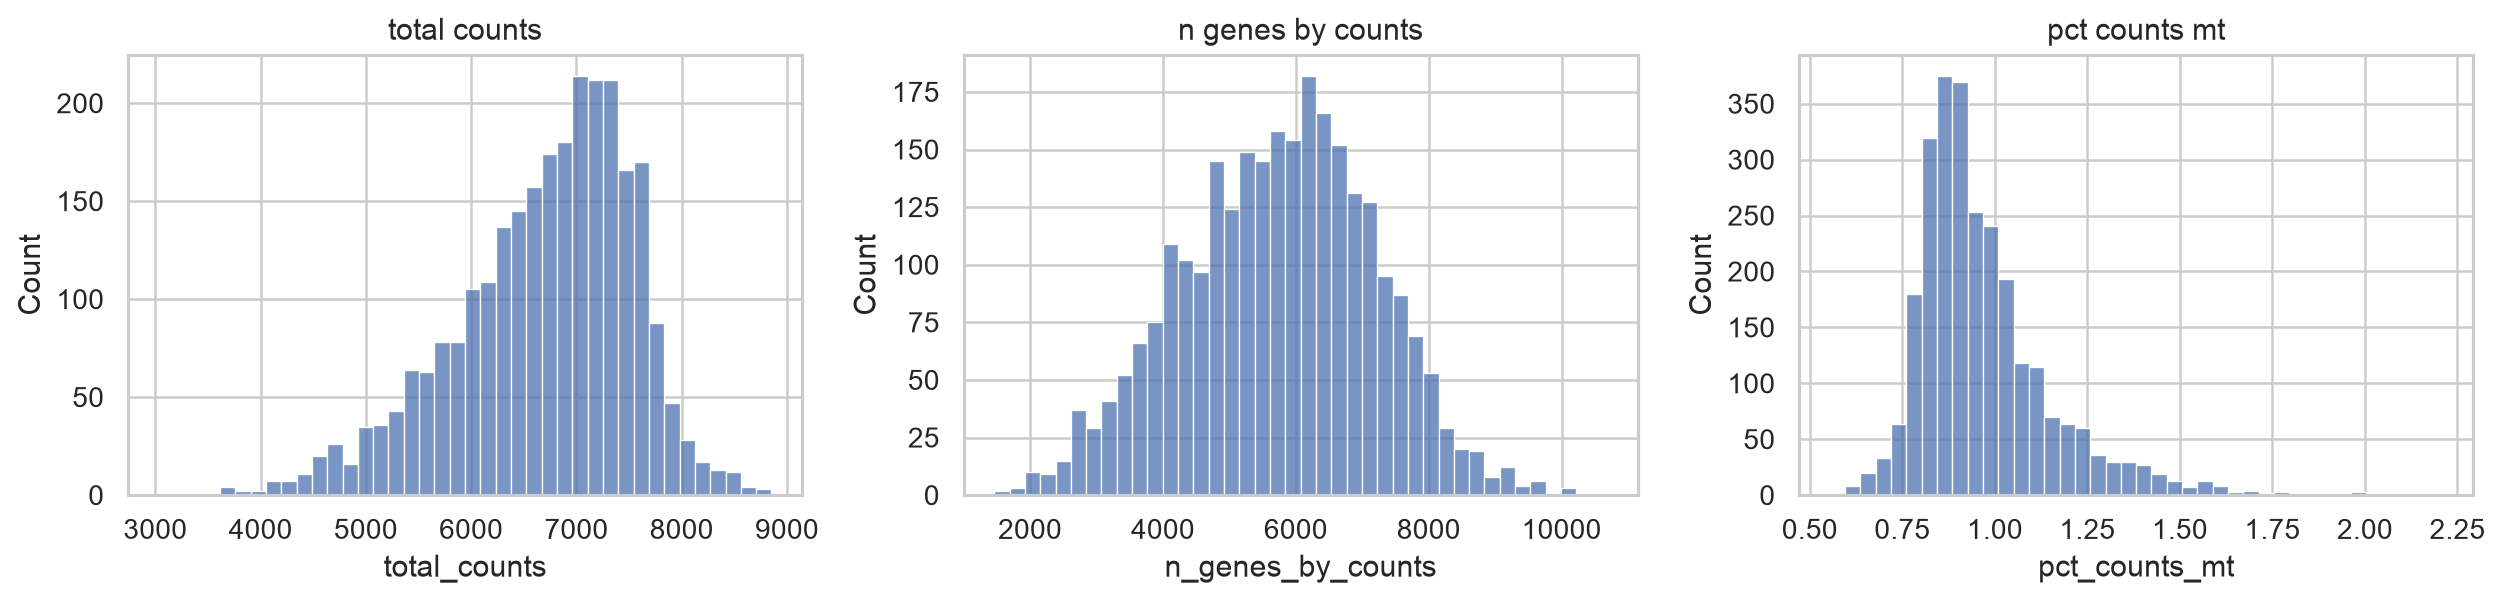

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for column, ax in zip(qc_columns, axes):
    sns.histplot(adata.obs[column], bins=40, ax=ax)
    ax.set_title(column.replace("_", " "))
plt.tight_layout()


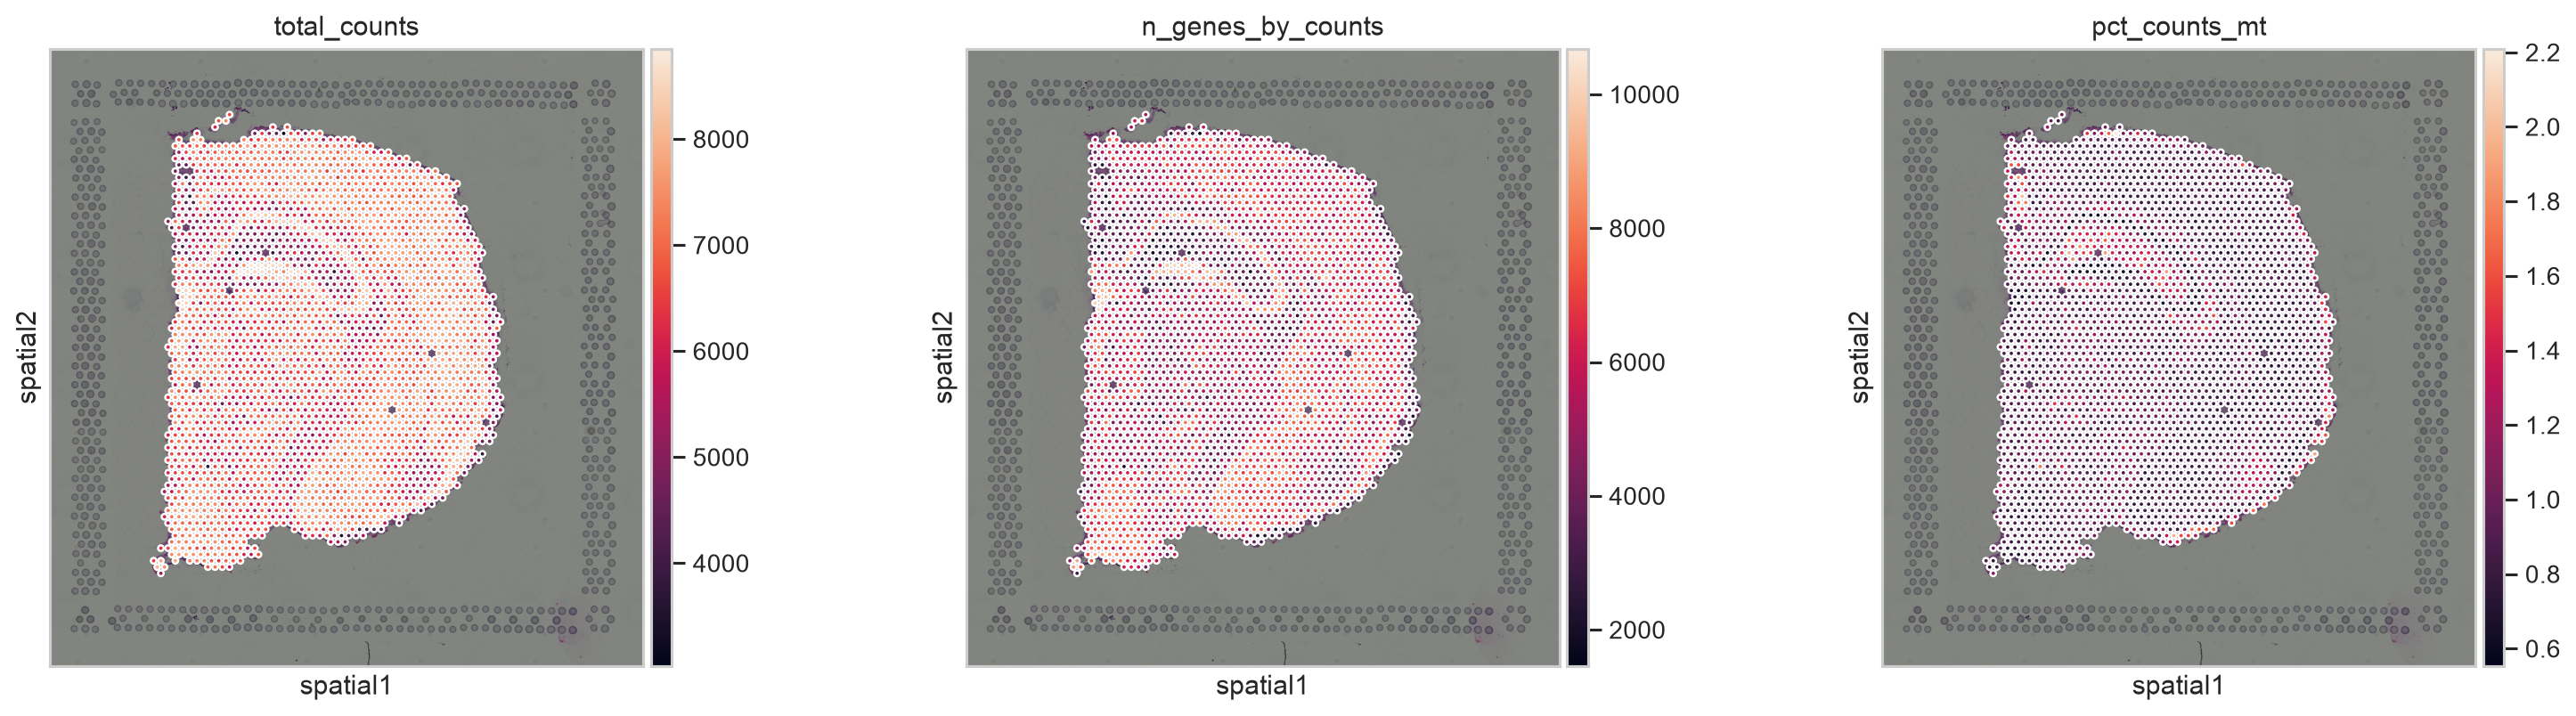

In [11]:
sq.pl.spatial_scatter(adata, color=qc_columns, ncols=3, size=1.2)


**Questions to ask:** Are low-quality spots concentrated at tissue edges? Does a high-count region follow anatomy, suggesting biology rather than a technical artifact? Spatial QC plots preserve context that histograms lose.


## 3. Put expression back onto the tissue

A spatial cluster groups spots with similar molecular profiles, but a cluster is not automatically a cell type. In spot-based Visium data, each spot can mix several cells. Anatomical labels require evidence from marker genes, histology, and reference atlases.


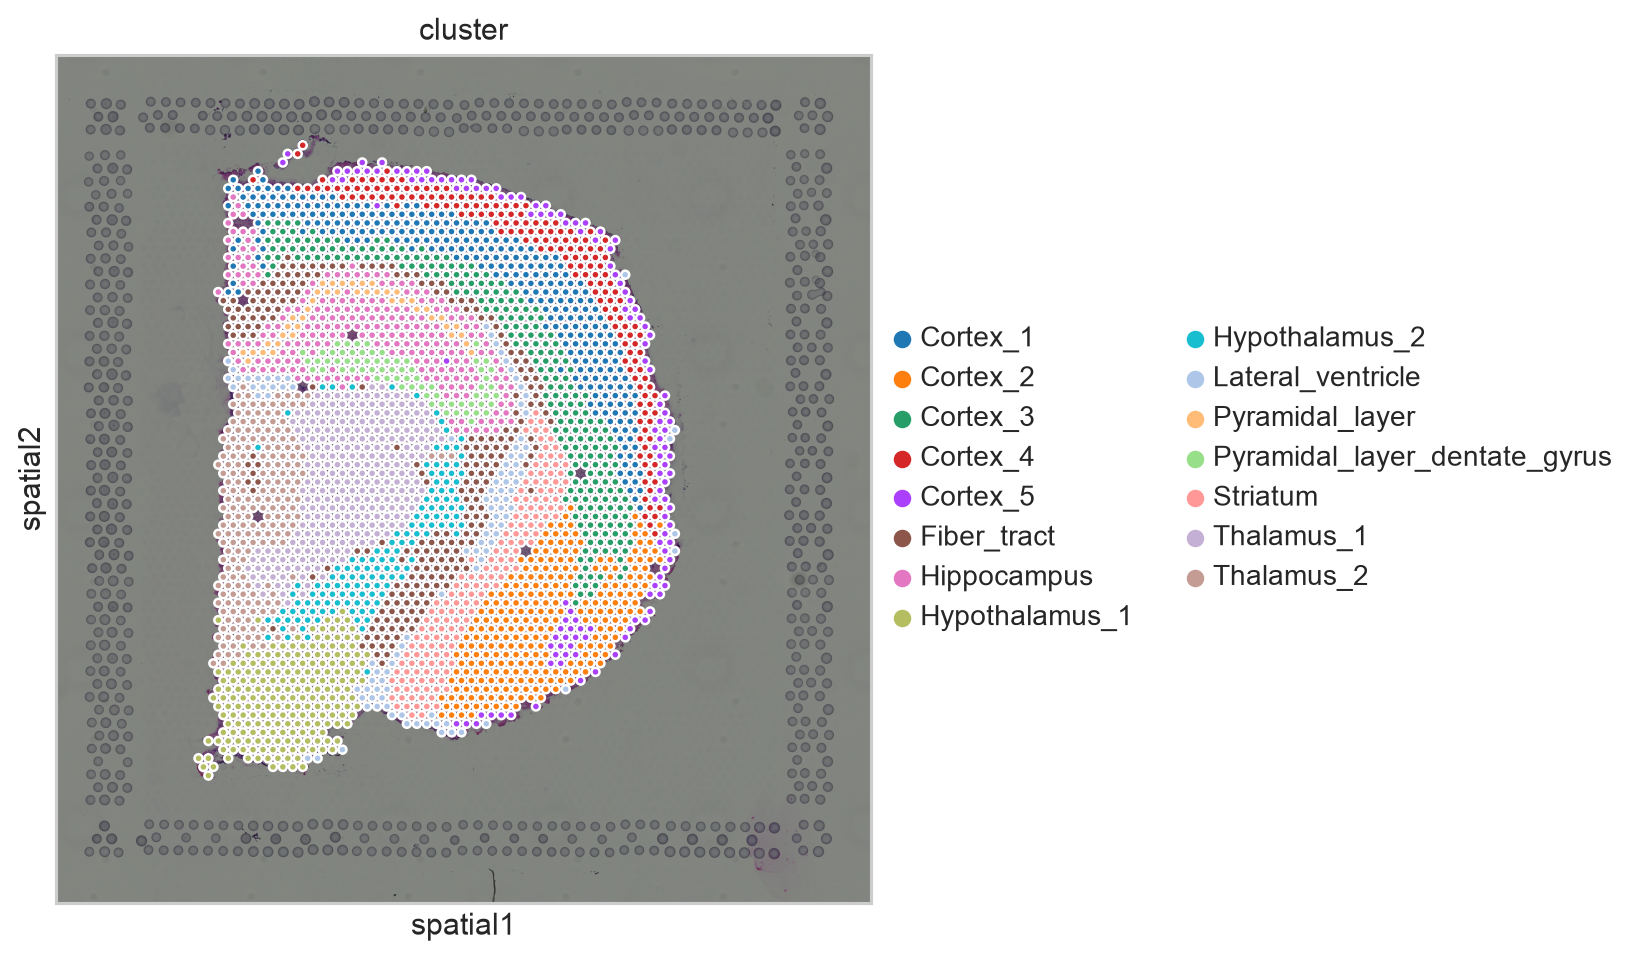

In [12]:
sq.pl.spatial_scatter(adata, color="cluster", size=1.25, figsize=(9, 7))


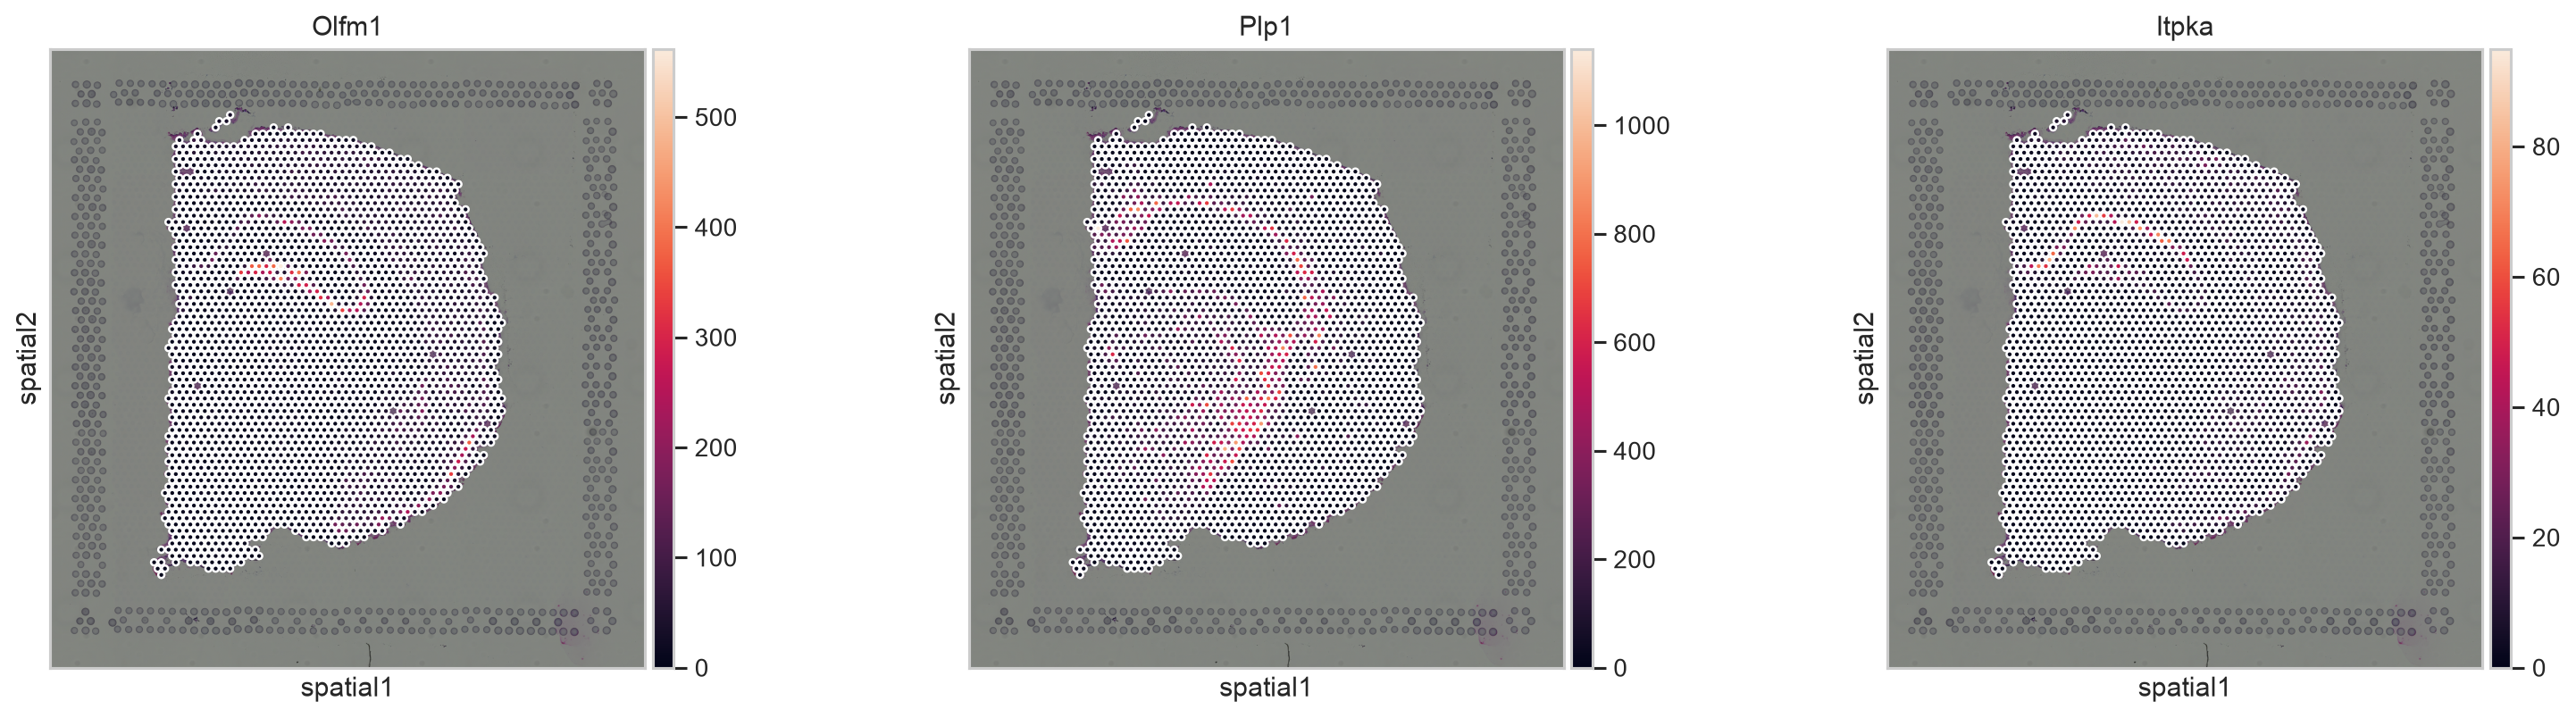

In [13]:
candidate_genes = [g for g in ["Olfm1", "Plp1", "Itpka"] if g in adata.var_names]
sq.pl.spatial_scatter(adata, color=candidate_genes, ncols=3, size=1.3)


**Interpretation:** a convincing spatial marker forms a coherent tissue pattern rather than isolated high-expression spots. A pattern is evidence for spatial organization, not by itself proof of mechanism.


## 4. Build a spatial-neighbor graph

A graph represents each spot as a node and nearby spots as edges. On a Visium grid, Squidpy uses the known lattice arrangement. This lets us ask whether labels or expression are arranged non-randomly in space.


In [14]:
sq.gr.spatial_neighbors(adata, coord_type="grid")
connectivities = adata.obsp["spatial_connectivities"]
degrees = connectivities.sum(axis=1).A1
pd.Series(degrees, name="spatial_neighbors").describe().round(2)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/var/folders/wg/rj6s_ttd799b8s260qqpc14m0000gn/T/ipykernel_20446/3541728083.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata, coord_type="grid")


count    2688.00
mean        5.80
std         0.68
min         1.00
25%         6.00
50%         6.00
75%         6.00
max         6.00
Name: spatial_neighbors, dtype: float64

Interior spots generally have more neighbors than edge spots. Always verify graph construction: grid adjacency, distance, and k-nearest neighbors encode different assumptions.


## 5. Neighborhood enrichment

Neighborhood enrichment compares observed label-to-label contacts with contacts expected after permuting labels. Positive z-scores mean two regions touch more often than expected; negative scores indicate avoidance. This is association, not evidence of cellular communication.


  0%|          | 0/100 [00:00<?, ?/s]/opt/anaconda3/envs/spatial-transcriptomics-demo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/anaconda3/envs/spatial-transcriptomics-demo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
100%|██████████| 100/100 [00:06<00:00, 16.09/s]


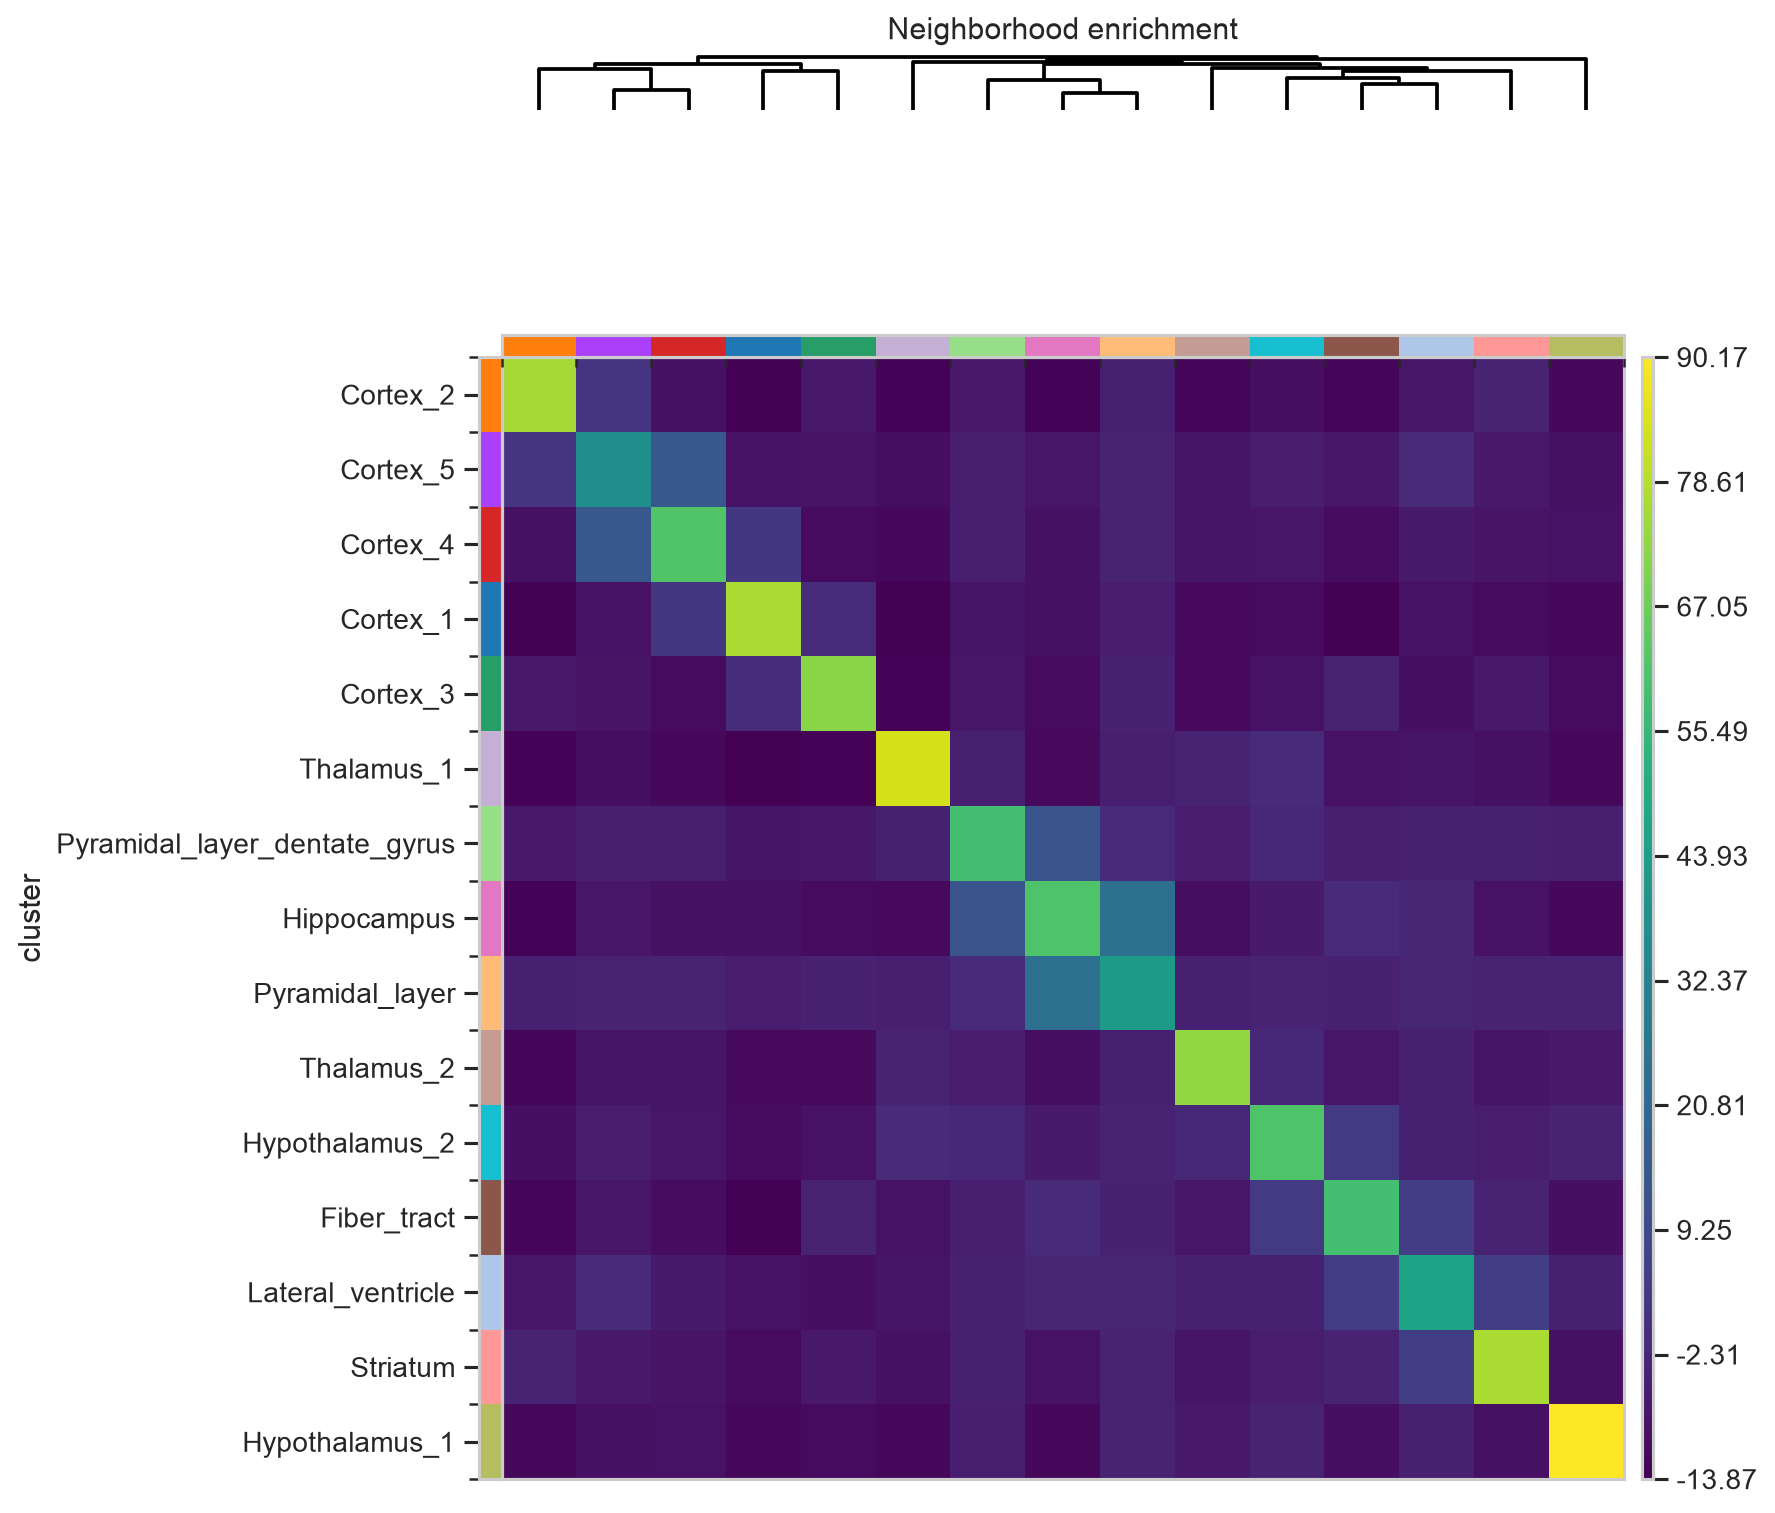

In [15]:
sq.gr.nhood_enrichment(adata, cluster_key="cluster", n_perms=100, seed=42)
sq.pl.nhood_enrichment(adata, cluster_key="cluster", method="ward", figsize=(8, 8))


## 6. Spatially variable genes with Moran's I

Moran's I measures whether similar values occur near one another. Values above the random expectation indicate positive spatial autocorrelation. We test a subset of highly variable genes to keep the tutorial quick. Adjusted p-values matter because many genes are evaluated.


In [16]:
if "highly_variable" in adata.var:
    tested_genes = adata.var_names[adata.var["highly_variable"]][:200].tolist()
else:
    tested_genes = adata.var_names[:200].tolist()

sq.gr.spatial_autocorr(
    adata, mode="moran", genes=tested_genes, n_perms=50, n_jobs=1, seed=42
)
moran_results = adata.uns["moranI"].copy()
moran_results.head(10)


  0%|          | 0/50 [00:00<?, ?/s]/opt/anaconda3/envs/spatial-transcriptomics-demo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/opt/anaconda3/envs/spatial-transcriptomics-demo/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
100%|██████████| 50/50 [00:12<00:00,  3.86/s]


,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh
Dbi,0.672365,0.0,0.000131,0.0,0.019608,0.000299,0.0,0.0,0.023912
3110035E14Rik,0.665132,0.0,0.000131,0.0,0.019608,0.000297,0.0,0.0,0.023912
Resp18,0.649582,0.0,0.000131,0.0,0.019608,0.000202,0.0,0.0,0.023912
Lypd1,0.620245,0.0,0.000131,0.0,0.019608,0.000282,0.0,0.0,0.023912
1500015O10Rik,0.605940,0.0,0.000131,0.0,0.019608,0.000200,0.0,0.0,0.023912
Ngef,0.604540,0.0,0.000131,0.0,0.019608,0.000263,0.0,0.0,0.023912
Ecel1,0.570304,0.0,0.000131,0.0,0.019608,0.000170,0.0,0.0,0.023912
Kcnj13,0.563886,0.0,0.000131,0.0,0.019608,0.000166,0.0,0.0,0.023912
Csrp1,0.543358,0.0,0.000131,0.0,0.019608,0.000207,0.0,0.0,0.023912
2010300C02Rik,0.539469,0.0,0.000131,0.0,0.019608,0.000237,0.0,0.0,0.023912


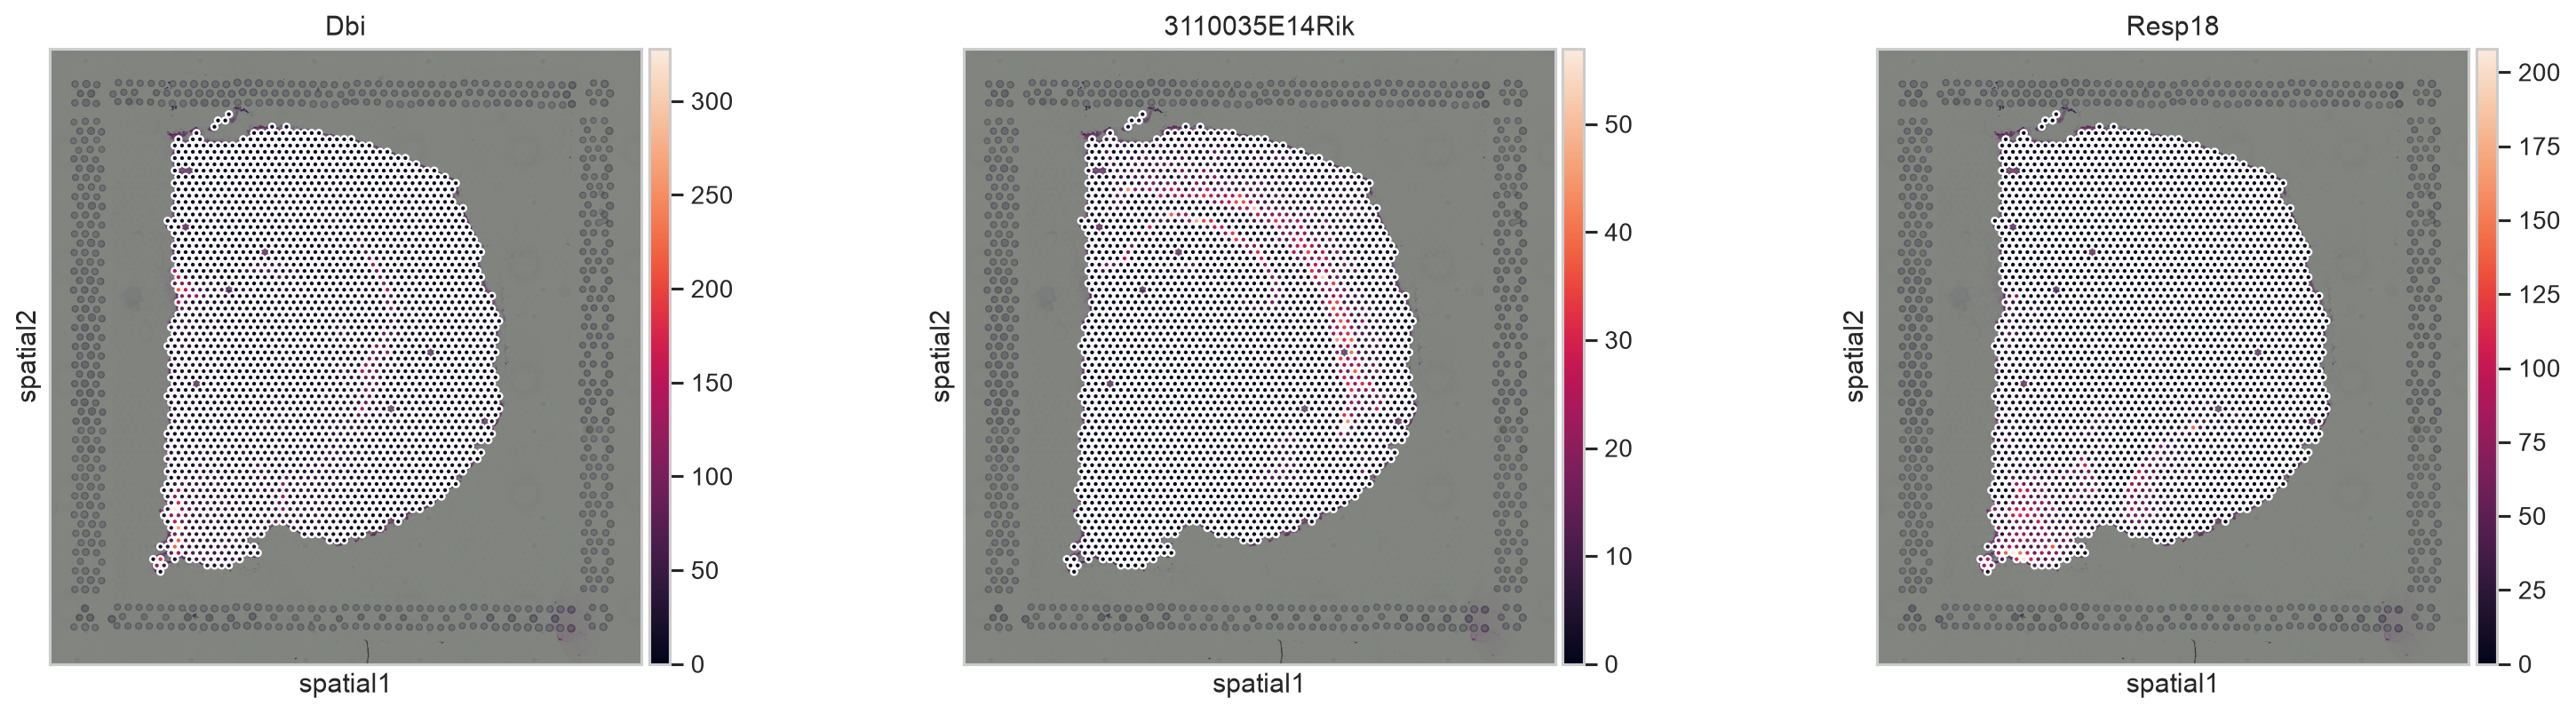

In [17]:
top_spatial_genes = moran_results.head(3).index.tolist()
sq.pl.spatial_scatter(adata, color=top_spatial_genes, ncols=3, size=1.3)


## Biological interpretation of the Moran's I hits

### Result worth remembering

> **`Dbi` was the strongest gene in this tested subset: Moran's I = 0.672.**

The highlighted annotated genes below span approximately **0.57–0.67**, indicating substantial positive spatial autocorrelation: nearby spots tend to have similar expression values.

| Gene | Moran's I | Biological context |
|---|---:|---|
| `Dbi` | 0.672 | Diazepam-binding inhibitor/acyl-CoA-binding protein. It is expressed in brain and has reported roles in GABAergic signaling and hippocampal synaptic inhibition. |
| `Resp18` | 0.650 | Regulated endocrine-specific protein 18; originally described as having expression limited to neural and endocrine tissue and associated with regulated secretory biology. |
| `Lypd1` | 0.620 | A Ly6/uPAR-domain gene with nervous-system expression; its spatial pattern is more informative here than its name alone. |
| `Ngef` | 0.605 | Neuronal guanine-nucleotide exchange factor; linked to signaling during differentiation of specific telencephalic neuronal populations. |
| `Ecel1` | 0.570 | Endothelin-converting enzyme-like 1, a neuronal gene associated with nervous-system development and motor-neuron biology. |

Several of the strongest **annotated** hits therefore have neural or neuroendocrine relevance. That is biologically coherent for a mouse-brain section and serves as a useful **sanity check**: the spatial statistic is recovering structured signals with plausible tissue biology.

However, this is not proof that every top hit is brain-specific. The ranking also contains poorly characterized RIKEN genes (`3110035E14Rik`, `1500015O10Rik`, `2010300C02Rik`) and broadly functioning genes such as `Csrp1`. Gene-name plausibility is supportive interpretation, not independent validation.

### What the result means—and does not mean

- Moran's I measures **spatial organization**, not expression magnitude or causality.
- `Dbi = 0.672` means nearby spots tend to have similar `Dbi` expression in this tissue section.
- The test covered only the first 200 highly variable genes, not the whole transcriptome.
- Spatial structure could reflect anatomy, cell-type composition, local regulation, or technical gradients.
- Strong biological interpretation requires examining the tissue pattern, histology, marker context, replicates, and external evidence.

### Annotation references

- [`Dbi`, NCBI Gene](https://www.ncbi.nlm.nih.gov/gene/13167) and [hippocampal synaptic-inhibition study](https://pubmed.ncbi.nlm.nih.gov/30031126/)
- [`Resp18`, Mouse Genome Informatics](https://www.informatics.jax.org/marker/MGI%3A1098222) and [original neural/endocrine expression study](https://pubmed.ncbi.nlm.nih.gov/8132649/)
- [`Lypd1`, NCBI Gene](https://www.ncbi.nlm.nih.gov/gene/72585)
- [`Ngef` neuronal-differentiation study](https://pubmed.ncbi.nlm.nih.gov/14643017/)
- [`Ecel1`, NCBI Gene](https://www.ncbi.nlm.nih.gov/gene/13599)


**Interpretation:** high Moran's I says expression is spatially structured. It does not say why. Anatomy, cell-type composition, technical gradients, or spatial regulation could all cause the pattern.


## Exercise: investigate one anatomical region

1. Choose a cluster from `adata.obs['cluster']`.
2. Report its number and percentage of spots.
3. Find the cluster with which it has the highest off-diagonal enrichment z-score.
4. In 2–3 sentences, explain what the result does and does not establish.

Try this yourself before revealing the scaffold below.


In [18]:
# Exercise answer scaffold
chosen_cluster = "Hippocampus"
cluster_counts = adata.obs["cluster"].value_counts()
n_chosen = int(cluster_counts[chosen_cluster])
pct_chosen = 100 * n_chosen / adata.n_obs

enrichment = adata.uns["cluster_nhood_enrichment"]
cluster_names = adata.obs["cluster"].cat.categories
z_table = pd.DataFrame(enrichment["zscore"], index=cluster_names, columns=cluster_names)
best_neighbor = z_table.loc[chosen_cluster].drop(chosen_cluster).idxmax()

print(f"{chosen_cluster}: {n_chosen} spots ({pct_chosen:.1f}%)")
print(f"Strongest enriched neighbor: {best_neighbor}")
# Interpretation: These labels contact one another more often than expected
# under label permutation. This does not prove direct cell-cell signaling.


Hippocampus: 222 spots (8.3%)
Strongest enriched neighbor: Pyramidal_layer


## Common pitfalls and next steps

- **Spot ≠ cell:** Visium spots can mix cell types, so avoid single-cell claims.
- **Cluster ≠ cell type:** annotate with markers, histology, and references.
- **Spatial association ≠ mechanism:** adjacency does not prove communication.
- **Preprocessed ≠ valid for every question:** inspect transformations and raw-count availability before differential-expression testing.
- **One section ≠ replication:** biological conclusions require multiple sections or subjects.

**Optional extension:** choose one region, identify marker genes with Scanpy, then compare them with a trusted mouse-brain atlas. The next lesson should repeat QC and preprocessing from raw Visium counts.


## Knowledge check

1. Why is a Visium spot not equivalent to a cell?
2. What does the spatial-neighbor graph add to expression data?
3. What does a high Moran's I mean—and not mean?
4. Why plot QC metrics on tissue coordinates?
5. What evidence is needed to call a cluster a cell type?
